# Pathogen → BioAssay Master Table

This notebook builds a unified table mapping:

**Pathogen → Taxonomy ID (TaxID) → BioAssay ID (AID)**  

This notebook:
01. Creates a **Pathogen → Taxonomy ID** table and dictionary
02. Counts number of PubChem BioAssays per pathogen based on **user interface (UI)**
03. Counts number of PubChem BioAssays per pathogen based on **manual taxonomy search**
04. Counts number of PubChem BioAssays per pathogen based on **PUG-REST taxonomy search**
05. Counts number of PubChem BioAssays per pathogen based on **PubChem’s official FTP file `Aid2Taxid.tsv.gz`**


## 0. Setup

In [62]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import json
import requests
import re
from bs4 import BeautifulSoup

In [ ]:
# Project paths
NOTEBOOK_DIR = Path().resolve()

DATA_RAW = NOTEBOOK_DIR.parent / "data" / "raw"
DATA_PROCESSED = NOTEBOOK_DIR.parent / "data" / "processed"

PUBCHEM_DIR = DATA_RAW / "pubchem_bioassays"
DESC_DIR = PUBCHEM_DIR / "Description"
DATA_DIR = PUBCHEM_DIR / "Data"

KEEP_DIR = DATA_RAW / "filtered_assays"
KEEP_DESC = KEEP_DIR / "Description"
KEEP_DATA = KEEP_DIR / "Data"

In [4]:
pathogens = [
    "Acinetobacter baumannii", "Candida albicans", "Campylobacter",
    "Escherichia coli", "Enterococcus faecium", "Enterobacter",
    "Helicobacter pylori", "Klebsiella pneumoniae",
    "Mycobacterium tuberculosis", "Neisseria gonorrhoeae",
    "Pseudomonas aeruginosa", "Plasmodium falciparum",
    "Staphylococcus aureus", "Schistosoma mansoni",
    "Streptococcus pneumoniae"
]

## 01. Build Pathogen Taxonomy Table

### 1.1. Manually download pathogen summary
PubChem does not currently expose a stable API for retrieving organism-linked BioAssays directly from organism names. Therefore, the initial files used here were exported manually from:

**PubChem → Search → "Organism name" → Taxonomy →  Download: *Summary (Search Results)***

Each exported CSV (such as `PubChem_taxonomy_text_Acinetobacter baumannii.csv`) has been manually saved under `data\raw` and it contains:
- `Taxonomy_ID`
- `Taxonomy_Name`


In [58]:
abaumanii_summary = pd.read_csv(DATA_RAW / f"PubChem_taxonomy_text_Acinetobacter baumannii.csv")
abaumanii_summary.head(1)

,Taxonomy_ID,Data_Source,type,Taxonomy_Name,Synonyms,Linked_BioAssays,Linked_Proteins,Linked_Genes,Linked_Pathways,pmids,Identifiers,dois,pmcids,pclids,citations
0,575584,BioAssay|Patent|Cooccurrence,1,Acinetobacter baumannii ATCC 19606 = CIP 70.34...,Acinetobacter baumannii ATCC 19606 = CIP 70.34...,1368269|1368280|1368291|1657590,D0C9N6|D0C9N8,NaN,NaN,NaN,UniProt:575584|Wikidata:Q124691247,NaN,NaN,NaN,NaN


### 1.2. Keep only pathogen name and taxonomy
Create a single Pathogen with associated taxonomies table

In [43]:
def pathogen_taxid(pathogen: str) -> pd.DataFrame:
    filename = f"PubChem_taxonomy_text_{pathogen}.csv"
    filepath = DATA_RAW / filename

    df = pd.read_csv(filepath)
    df["Pathogen"] = pathogen

    return df[["Pathogen", "Taxonomy_ID", "Taxonomy_Name"]].drop_duplicates()

In [44]:
pathogens_taxid_table = []

for pathogen in pathogens:
    print(f"Processing {pathogen}...")
    single_pathogen_taxid = pathogen_taxid(pathogen)
    pathogens_taxid_table.append(single_pathogen_taxid)

pathogens_taxid = pd.concat(pathogens_taxid_table, ignore_index=True)
pathogens_taxid = pathogens_taxid[["Pathogen", "Taxonomy_ID", "Taxonomy_Name"]]
pathogens_taxid

Processing Acinetobacter baumannii...
Processing Candida albicans...
Processing Campylobacter...
Processing Escherichia coli...
Processing Enterococcus faecium...
Processing Enterobacter...
Processing Helicobacter pylori...
Processing Klebsiella pneumoniae...
Processing Mycobacterium tuberculosis...
Processing Neisseria gonorrhoeae...
Processing Pseudomonas aeruginosa...
Processing Plasmodium falciparum...
Processing Staphylococcus aureus...
Processing Schistosoma mansoni...
Processing Streptococcus pneumoniae...


,Pathogen,Taxonomy_ID,Taxonomy_Name
0,Acinetobacter baumannii,575584,Acinetobacter baumannii ATCC 19606 = CIP 70.34...
1,Acinetobacter baumannii,1116234,Acinetobacter baumannii AB5075
2,Acinetobacter baumannii,1116236,Acinetobacter baumannii AB5711
3,Acinetobacter baumannii,400667,Acinetobacter baumannii ATCC 17978
4,Acinetobacter baumannii,405416,Acinetobacter baumannii ACICU
...,...,...,...
2285,Streptococcus pneumoniae,341698,Streptococcus phage MM1 1998
2286,Streptococcus pneumoniae,622691,Streptococcus phage SV1
2287,Streptococcus pneumoniae,1267169,Streptococcus phage phiBHN167
2288,Streptococcus pneumoniae,1461246,Streptococcus phage Spn1


In [12]:
pathogens_taxid.to_csv(DATA_PROCESSED / "pathogens_taxid.csv", index=False)

### 1.3. Manually clean taxonomy table
Some taxonomy captures with PubChem query do not match the expected pathogens and have to be manually eliminated:

In [4]:
wrong_taxonomies = {
    "Acinetobacter baumannii": {
        "Acinetobacter calcoaceticus/baumannii complex",
    },
    "Candida albicans": {
        "Candida tropicalis",
    },
    "Campylobacter": {
        "Helicobacter pylori",
        "Helicobacter mustelae",
        "Aliarcobacter cryaerophilus",
        "Helicobacter cinaedi",
        "Helicobacter fennelliae",
        "Aliarcobacter butzleri",
        "Arcobacter nitrofigilis",
        "Helicobacter sp. CLO-3",
        "Firehammervirus CP220",
        "Firehammervirus CPt10",
        "Fletchervirus NCTC12673",
        "Fletchervirus CP81",
        "Fletchervirus CPX",
        "Firehammervirus CP21",
        "Fletchervirus CP30A",
        "Fletchervirus Los1",
    },
    "Escherichia coli": {
        "Tequintavirus AKFV33",
        "Enterobacteria phage CUS-3",
    },
    "Enterococcus faecium": {
        "Enterococcus casseliflavus",
    },
    "Enterobacter": {
        "Hafnia alvei",
        "Kosakonia radicincitans DSM 16656",
        "Kluyvera intermedia",
        "Cronobacter sakazakii",
        "Pluralibacter gergoviae",
        "Klebsiella aerogenes EA1509E",
        "Klebsiella aerogenes KCTC 2190",
        "Klebsiella aerogenes",
        "Pantoea agglomerans",
        "Lelliottia amnigena",
        "Lelliottia nimipressuralis",
        "Pluralibacter pyrinus",
        "Kosakonia radicincitans",
        "Siccibacter turicensis",
        "Franconibacter helveticus",
        "Franconibacter pulveris",
        "Kosakonia oryzae",
        "Kosakonia arachidis",
        "Kosakonia sacchari",
        "Kosakonia sacchari SP1",
        "Escherichia phage IME11",
        "Pluralibacter gergoviae ATCC 33028 = NBRC 105706",
        "Phytobacter massiliensis",
        "Atlantibacter hermannii",
        "Rahnella aquatilis",
        "Kosakonia cowanii",
        "Cronobacter sakazakii ATCC BAA-894",
        "Kosakonia oryzendophytica",
        "Kosakonia oryziphila",
        "Webervirus F20",
        "Franconibacter pulveris DSM 19144",
        "Hafnia phage Enc34",
        "Pseudenterobacter timonensis",
        "Karamvirus pg7",
        "Karamvirus cc31",
        "Slopekvirus eap3",
        "Eclunavirus EcL1",
        "Eapunavirus Eap1",
    },
    "Helicobacter pylori": {
        "Helicobacter mustelae",
    },
    "Klebsiella pneumoniae": {
        "Klebsiella michiganensis KCTC 1686",
        "Klebsiella variicola subsp. tropica",
    },
    "Mycobacterium tuberculosis": {
        "Mycobacterium avium",
        "Corynebacterium pseudotuberculosis",
    },
    "Pseudomonas aeruginosa": {
        "Pseudomonas virus Yua",
    },
    "Staphylococcus aureus": {
        "Dubowvirus dv11",
    },
}

In [7]:
# Remove rows with unwanted pathogens-taxonomy pairs
pathogens_taxid = pd.read_csv(DATA_PROCESSED / "pathogens_taxid.csv")

df = pathogens_taxid.copy()
keep = pd.Series(True, index=df.index)

for pathogen, taxonomy in wrong_taxonomies.items():
    # rows that match THIS pathogen AND have a name in THIS pathogen's bad set
    to_drop = (df["Pathogen"] == pathogen) & (df["Taxonomy_Name"].isin(taxonomy))
    
    # set those rows to False (drop them)
    keep &= ~to_drop

removed_pairs_df = df[keep].reset_index(drop=True)

In [8]:
# Remove rows with "phage" or "virus"
is_phage_or_virus = removed_pairs_df["Taxonomy_Name"].str.contains(
    r"phage|virus"
)

clean_df = removed_pairs_df[~is_phage_or_virus].reset_index(drop=True)

In [9]:
clean_df.to_csv(DATA_PROCESSED / "pathogens_taxid_cleaned.csv", index=False)

In [17]:
# Convert taxonomy table into dictionary
pathogens_taxid_cleaned_dict = (
    clean_df.groupby("Pathogen")["Taxonomy_ID"]
    .apply(list)
    .to_dict()
)

with open(DATA_PROCESSED / "pathogens_taxid_cleaned_dict.json", "w") as f:
    json.dump(pathogens_taxid_cleaned_dict, f, indent=2)

## 02. AIDs per pathogen using PubChem user interface (UI)

In [25]:
# Add UI (user interface) counts (manually annotated 17.11.25)
ui_counts = {
    "Acinetobacter baumannii": 15778,
    "Candida albicans": 23814,
    "Campylobacter": 622,
    "Escherichia coli": 63263,
    "Enterococcus faecium": 3864,
    "Enterobacter": 4023,
    "Helicobacter pylori": 1670,
    "Klebsiella pneumoniae": 11883,
    "Mycobacterium tuberculosis": 25323,
    "Neisseria gonorrhoeae": 1019,
    "Pseudomonas aeruginosa": 26093,
    "Plasmodium falciparum": 24519,
    "Staphylococcus aureus": 59672,
    "Schistosoma mansoni": 1276,
    "Streptococcus pneumoniae": 9474
}

AIDs_pathogen = (pd.DataFrame(ui_counts.items(), columns=["Pathogen", "UI_AIDs"])
    .sort_values("UI_AIDs", ascending=False)
    .reset_index(drop=True)
)

AIDs_pathogen

,Pathogen,UI_AIDs
0,Escherichia coli,63263
1,Staphylococcus aureus,59672
2,Pseudomonas aeruginosa,26093
3,Mycobacterium tuberculosis,25323
4,Plasmodium falciparum,24519
5,Candida albicans,23814
6,Acinetobacter baumannii,15778
7,Klebsiella pneumoniae,11883
8,Streptococcus pneumoniae,9474
9,Enterobacter,4023


In [26]:
AIDs_pathogen.to_csv(DATA_PROCESSED / "aid_counts_all_pathogens.csv", index=False)

## 03. AIDs per pathogen using PubChem Taxonomy search

PubChem does not currently expose a stable API for retrieving organism-linked BioAssays directly from organism names. Therefore, the initial files used here were exported manually from:

**PubChem → Search → "Organism name" → Taxonomy →  Download: *Summary (Search Results)***

Each exported CSV (such as `PubChem_taxonomy_text_Acinetobacter baumannii.csv`) has been manually saved under `data\raw`.

Each CSV contains a pipe-separated list of linked BioAssays. 

We expand these to one row per AID and annotate with the pathogen name.

Now, we will NOT filter out the wrong taxonomies we have manually filtered, in order to compare it with the UI_AIDs.

In [8]:
def taxid_aid(pathogen: str) -> pd.DataFrame:
    """Expand the PubChem Taxonomy→BioAssay mapping for a pathogen
    """

    df = pd.read_csv(DATA_RAW / f"PubChem_taxonomy_text_{pathogen}.csv")

    # Fill empty rows with empty strings "" (if no linked_bioassay, no rows for that pathogen to be counted)
    df["Linked_BioAssays"] = df["Linked_BioAssays"].fillna("")

    # Split into python list (from "1234|5678|9012" to ["1234", "5678", "9012"])
    df["AID"] = df["Linked_BioAssays"].astype(str).str.split("|")
    
    # Expand AIDs (one row per AID)
    df = df.explode("AID")

    df["Pathogen"] = pathogen

    return df[["Pathogen", "Taxonomy_ID", "Taxonomy_Name", "AID"]].drop_duplicates()

In [10]:
# Process all pathogens and create single table

pathogen_tables = []

for pathogen in pathogens:
    pathogen_table = taxid_aid(pathogen)
    pathogen_tables.append(pathogen_table)

all_pathogens = pd.concat(pathogen_tables, ignore_index=True)
all_pathogens = all_pathogens[["Pathogen", "Taxonomy_ID", "Taxonomy_Name", "AID"]]
all_pathogens.head()

,Pathogen,Taxonomy_ID,Taxonomy_Name,AID
0,Acinetobacter baumannii,575584,Acinetobacter baumannii ATCC 19606 = CIP 70.34...,1368269
1,Acinetobacter baumannii,575584,Acinetobacter baumannii ATCC 19606 = CIP 70.34...,1368280
2,Acinetobacter baumannii,575584,Acinetobacter baumannii ATCC 19606 = CIP 70.34...,1368291
3,Acinetobacter baumannii,575584,Acinetobacter baumannii ATCC 19606 = CIP 70.34...,1657590
4,Acinetobacter baumannii,1116234,Acinetobacter baumannii AB5075,


In [16]:
# Count number of AIDs per pathogen
taxid_counts = (
    all_pathogens.groupby("Pathogen")["AID"]
    .nunique()
    .reset_index(name="Taxonomy_AIDs")
    .sort_values("Taxonomy_AIDs", ascending=False)
    .reset_index(drop=True)
)

taxid_counts

,Pathogen,Taxonomy_AIDs
0,Mycobacterium tuberculosis,3809
1,Escherichia coli,3416
2,Candida albicans,3115
3,Pseudomonas aeruginosa,2415
4,Enterobacter,2258
5,Plasmodium falciparum,1968
6,Staphylococcus aureus,1897
7,Streptococcus pneumoniae,1585
8,Klebsiella pneumoniae,1536
9,Acinetobacter baumannii,1443


In [27]:
# Merge with previous AID counts
AIDs_pathogen = AIDs_pathogen.merge(
    taxid_counts,
    on="Pathogen",
    how="left"   # keep all pathogens from AIDs_pathogen
)

AIDs_pathogen

,Pathogen,UI_AIDs,Taxonomy_AIDs
0,Escherichia coli,63263,3416
1,Staphylococcus aureus,59672,1897
2,Pseudomonas aeruginosa,26093,2415
3,Mycobacterium tuberculosis,25323,3809
4,Plasmodium falciparum,24519,1968
5,Candida albicans,23814,3115
6,Acinetobacter baumannii,15778,1443
7,Klebsiella pneumoniae,11883,1536
8,Streptococcus pneumoniae,9474,1585
9,Enterobacter,4023,2258


In [28]:
AIDs_pathogen.to_csv(DATA_PROCESSED / "aid_counts_all_pathogens.csv", index=False)

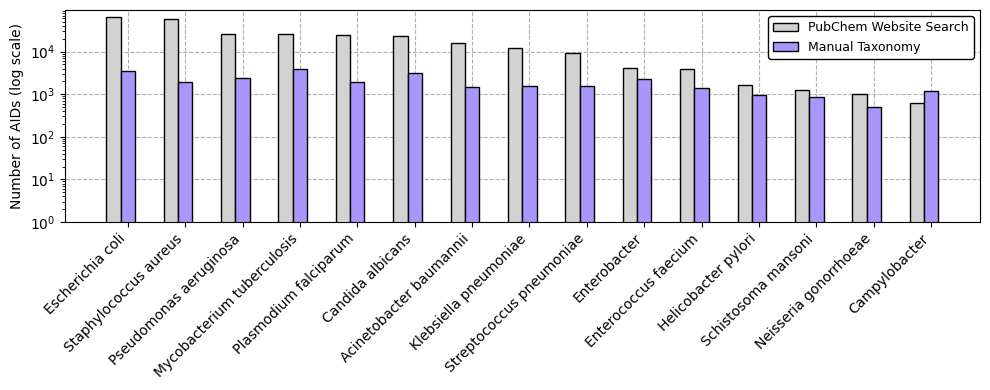

In [33]:
# Extract arrays
labels = AIDs_pathogen["Pathogen"].values
UI_AIDs = AIDs_pathogen["UI_AIDs"].values
Taxonomy_AIDs = AIDs_pathogen["Taxonomy_AIDs"].values

N = len(labels)
x = np.arange(N)

bar_width = 0.25

plt.figure(figsize=(10, 4))

plt.bar(
    x - bar_width,
    UI_AIDs,
    width=bar_width,
    color="#D2D2D2",
    ec="black",
    zorder=2,
    label="PubChem Website Search"
)

plt.bar(
    x,
    Taxonomy_AIDs,
    width=bar_width,
    color="#AA96FA",
    ec="black",
    zorder=2,
    label="Manual Taxonomy"
)

# Aesthetics
plt.yscale("log")
plt.ylim([1, UI_AIDs.max() * 1.5])

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Number of AIDs (log scale)")

plt.grid(linestyle="--", zorder=1)
plt.legend(loc="upper right", framealpha=1, edgecolor="k", prop={"size": 9})

plt.tight_layout()
plt.show()

## 04. SDQ Query for Bioassays aid & taxids
PubChem provides a programmatic interface (PUG-REST) for retrieving BioAssay identifiers (AIDs) linked to NCBI Taxonomy IDs, but not directly from organism names.

In this step, we will:

1.	Use the curated set of NCBI Taxonomy IDs associated with each pathogen (`pathogens_taxid_cleaned_dict.json`).

2.	Query PubChem’s taxonomy → taxid → AIDs endpoint via PUG-REST for each TaxID

3.	Retrieve the list of BioAssay IDs associated with each TaxID.

4.	Aggregate and deduplicate AIDs across all TaxIDs belonging to the same pathogen.

This approach avoids manual UI exports and enables fully reproducible retrieval of organism-linked BioAssays directly from PubChem.

Unlike the previous section, here we rely exclusively on curated Taxonomy IDs and programmatic access.

In [29]:
def get_aids_for_taxid(taxid: int):
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/taxonomy/taxid/{taxid}/aids/JSON"

    try:
        r = requests.get(url, timeout=15)
    except requests.exceptions.RequestException:
        return []

    if r.status_code != 200:
        return []

    try:
        data = r.json()
        info = data["InformationList"]["Information"][0]
        return info.get("AID", [])
    except:
        return []

In [ ]:
# For each pathogen, fetch curated AIDs (ETA: 25min)
pugrest_counts = {}

with open(DATA_PROCESSED / "pathogens_taxid_cleaned_dict.json", "r") as f:
    dict_taxonomy = json.load(f)

for pathogen, taxids in dict_taxonomy.items():
    aids = set()
    for tid in taxids:
        aids.update(get_aids_for_taxid(tid))
    pugrest_counts[pathogen] = len(aids)

pugrest_counts

In [35]:
# Merge with previous AID counts
pugrest_counts_df = (pd.DataFrame(pugrest_counts.items(), columns=["Pathogen", "PUGREST_AIDs"]))

AIDs_pathogen = AIDs_pathogen.merge(
    pugrest_counts_df,
    on="Pathogen",
    how="left"   # keep all pathogens from AIDs_pathogen
)

AIDs_pathogen

,Pathogen,UI_AIDs,Taxonomy_AIDs,PUGREST_AIDs
0,Escherichia coli,63263,3416,17850
1,Staphylococcus aureus,59672,1897,30774
2,Pseudomonas aeruginosa,26093,2415,12526
3,Mycobacterium tuberculosis,25323,3809,10290
4,Plasmodium falciparum,24519,1968,8229
5,Candida albicans,23814,3115,11878
6,Acinetobacter baumannii,15778,1443,3286
7,Klebsiella pneumoniae,11883,1536,5360
8,Streptococcus pneumoniae,9474,1585,4012
9,Enterobacter,4023,2258,1922


In [36]:
AIDs_pathogen.to_csv(DATA_PROCESSED / "aid_counts_all_pathogens.csv", index=False)

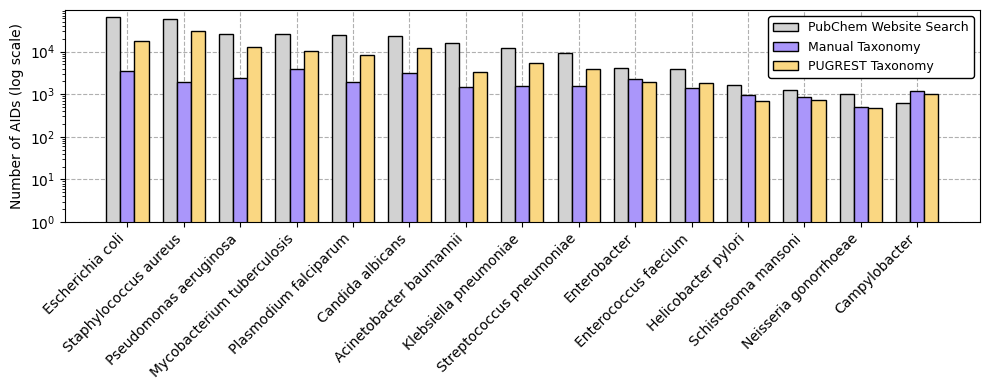

In [37]:
# Extract arrays
labels = AIDs_pathogen["Pathogen"].values
UI_AIDs = AIDs_pathogen["UI_AIDs"].values
Taxonomy_AIDs = AIDs_pathogen["Taxonomy_AIDs"].values
PUGREST_AIDs = AIDs_pathogen["PUGREST_AIDs"].values

N = len(labels)
x = np.arange(N)

bar_width = 0.25

plt.figure(figsize=(10, 4))

plt.bar(
    x - bar_width,
    UI_AIDs,
    width=bar_width,
    color="#D2D2D2",
    ec="black",
    zorder=2,
    label="PubChem Website Search"
)

plt.bar(
    x,
    Taxonomy_AIDs,
    width=bar_width,
    color="#AA96FA",
    ec="black",
    zorder=2,
    label="Manual Taxonomy"
)

plt.bar(
    x + bar_width,
    PUGREST_AIDs,
    width=bar_width,
    color="#FAD782",
    ec="black",
    zorder=2,
    label="PUGREST Taxonomy"
)

# Aesthetics
plt.yscale("log")
plt.ylim([1, UI_AIDs.max() * 1.5])

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Number of AIDs (log scale)")

plt.grid(linestyle="--", zorder=1)
plt.legend(loc="upper right", framealpha=1, edgecolor="k", prop={"size": 9})

plt.tight_layout()
plt.show()

## 05.PubChem’s Aid2Taxid.tsv.gz file

To obtain a complete list of all BioAssays linked to our taxonomy IDs, we now switch to PubChem’s official FTP file `Aid2Taxid.tsv.gz`, which contains the full mapping of every PubChem BioAssay to all associated NCBI Taxonomy IDs.

This file was downloaded manually from:

https://ftp.ncbi.nlm.nih.gov/pubchem/Bioassay/Extras/Aid2Taxid.gz

In [45]:
# Load file
df_aid2tax = pd.read_csv(DATA_RAW / "Aid2Taxid.tsv", sep="\t")
df_aid2tax = df_aid2tax.rename(columns={"TaxID": "Taxonomy_ID"})
df_aid2tax.head(10)

,AID,Taxonomy_ID
0,1398771,10090
1,1398772,10090
2,1398788,9606
3,1398789,9606
4,1398790,9606
5,1398791,9606
6,1398805,9606
7,1398806,9606
8,1398808,9606
9,1398822,9606


In [ ]:
# Build pathogen–TaxID lookup
pathogens_taxid = pd.read_csv(DATA_PROCESSED / "pathogens_taxid.csv")

df_merged = df_aid2tax.merge(
    pathogens_taxid[["Pathogen", "Taxonomy_ID"]],
    on="Taxonomy_ID",
    how="inner"
)

df_merged

,AID,Taxonomy_ID,Pathogen
0,1399257,1280,Staphylococcus aureus
1,1399258,1313,Streptococcus pneumoniae
2,1399258,171101,Streptococcus pneumoniae
3,1399274,562,Escherichia coli
4,1399275,562,Escherichia coli
...,...,...,...
108282,556690,548,Enterobacter
108283,556873,548,Enterobacter
108284,450447,244320,Escherichia coli
108285,57587,562,Escherichia coli


In [48]:
# Count AIDs per pathogen
aid2tax_counts = (
    df_merged.groupby("Pathogen")["AID"]
    .nunique()
    .reset_index(name="Aid2Taxid_AIDs")
    .sort_values("Aid2Taxid_AIDs", ascending=False)
    .reset_index(drop=True)
)

aid2tax_counts

,Pathogen,Aid2Taxid_AIDs
0,Staphylococcus aureus,26830
1,Escherichia coli,20163
2,Pseudomonas aeruginosa,11161
3,Candida albicans,10449
4,Mycobacterium tuberculosis,10040
5,Plasmodium falciparum,8150
6,Klebsiella pneumoniae,4477
7,Streptococcus pneumoniae,4193
8,Acinetobacter baumannii,2422
9,Enterobacter,1863


In [49]:
# Merge with previous AID counts
AIDs_pathogen = AIDs_pathogen.merge(
    aid2tax_counts,
    on="Pathogen",
    how="left"   # keep all pathogens from AIDs_pathogen
)

AIDs_pathogen

,Pathogen,UI_AIDs,Taxonomy_AIDs,PUGREST_AIDs,Aid2Taxid_AIDs
0,Escherichia coli,63263,3416,17850,20163
1,Staphylococcus aureus,59672,1897,30774,26830
2,Pseudomonas aeruginosa,26093,2415,12526,11161
3,Mycobacterium tuberculosis,25323,3809,10290,10040
4,Plasmodium falciparum,24519,1968,8229,8150
5,Candida albicans,23814,3115,11878,10449
6,Acinetobacter baumannii,15778,1443,3286,2422
7,Klebsiella pneumoniae,11883,1536,5360,4477
8,Streptococcus pneumoniae,9474,1585,4012,4193
9,Enterobacter,4023,2258,1922,1863


In [50]:
AIDs_pathogen.to_csv(DATA_PROCESSED / "aid_counts_all_pathogens.csv", index=False)

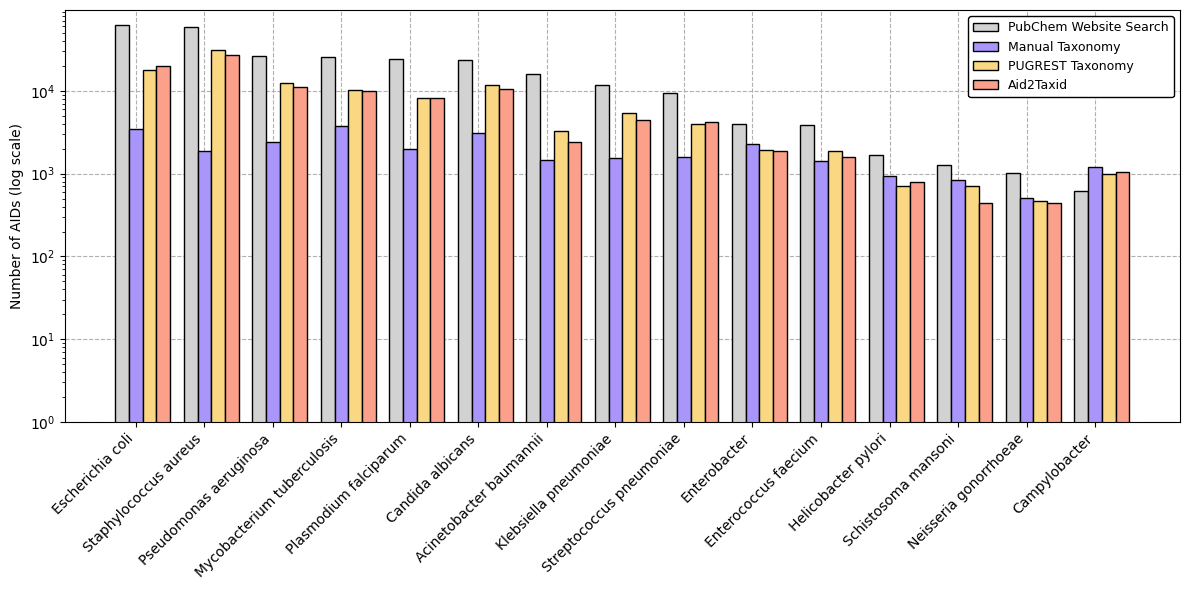

In [57]:
# Extract arrays
labels = AIDs_pathogen["Pathogen"].values
UI_AIDs = AIDs_pathogen["UI_AIDs"].values
Taxonomy_AIDs = AIDs_pathogen["Taxonomy_AIDs"].values
PUGREST_AIDs = AIDs_pathogen["PUGREST_AIDs"].values
PUGREST_AIDs = AIDs_pathogen["PUGREST_AIDs"].values
Aid2Taxid_AIDs = AIDs_pathogen["Aid2Taxid_AIDs"].values

N = len(labels)
x = np.arange(N)

bar_width = 0.2

plt.figure(figsize=(12, 6))

plt.bar(
    x - bar_width,
    UI_AIDs,
    width=bar_width,
    color="#D2D2D2",
    ec="black",
    zorder=2,
    label="PubChem Website Search"
)

plt.bar(
    x,
    Taxonomy_AIDs,
    width=bar_width,
    color="#AA96FA",
    ec="black",
    zorder=2,
    label="Manual Taxonomy"
)

plt.bar(
    x + bar_width,
    PUGREST_AIDs,
    width=bar_width,
    color="#FAD782",
    ec="black",
    zorder=2,
    label="PUGREST Taxonomy"
)

plt.bar(
    x + 2*bar_width,
    Aid2Taxid_AIDs,
    width=bar_width,
    color="#FAA08B",
    ec="black",
    zorder=2,
    label="Aid2Taxid"
)

# Aesthetics
plt.yscale("log")
plt.ylim([1, UI_AIDs.max() * 1.5])

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Number of AIDs (log scale)")

plt.grid(linestyle="--", zorder=1)
plt.legend(loc="upper right", framealpha=1, edgecolor="k", prop={"size": 9})

plt.tight_layout()
plt.show()

The comparison shows that the **manual taxonomy** export captures the fewest assays, while both **PUG REST** and **Aid2Taxid.tsv** recover many more—almost identical to each other—because they rely on the same structured taxonomy annotations deposited in PubChem.

However, both still fall below the counts shown on the **PubChem website**, meaning many assays mentioning a pathogen are not formally annotated with a `TaxID` and only appear in the website search because they contain the organism name somewhere in their free-text descriptions.

## 06. Downloading ALL PubChem locally

### 6.1. Understanding PubChem BioAssay FTP Folder Structure

PubChem stores all BioAssay files here:

**Descriptions** (XML): https://ftp.ncbi.nlm.nih.gov/pubchem/Bioassay/CSV/Description/

**Data** (CSV assay results): https://ftp.ncbi.nlm.nih.gov/pubchem/Bioassay/CSV/Data/

Inside each folder files look like:

Each zip file corresponds to a range of AIDs. Example:

`0000001_0001000.zip`  → contains assays with AID 1 to 1000

In `Description/`, there are files such as:

Each `*.descr.xml` file follows the official PubChem BioAssay XML schema and may contain detailed metadata describing the assay. Depending on the assay, the XML can include:

Always present (schema-required)
- **Assay Name**: `<PC-AssayDescription_name>`
- **Assay Description / Protocol text**: `<PC-AssayDescription_description>` (may include protocol steps, summary, conditions, etc.)
- **Depositor / Source Information**: `<PC-AssayDescription_aid-source>`


Present when deposited by submitter (schema-optional)
- **Targets** (proteins, genes, taxonomy IDs):` <PC-AssayDescription_target>`
- **Comments / Additional notes**: `<PC-AssayDescription_comment>`
- **References** (PMIDs, DOIs, citation links): `<PC-AssayDescription_xref>`
- **Relations to other assays**: `<PC-AssayDescription_relations>`

In `Data/`, there are files like:

Each .csv contains the assay results:

Columns 1–7:
- `PUBCHEM_RESULT_TAG`
- `PUBCHEM_SID`
- `PUBCHEM_CID`
- `PUBCHEM_ACTIVITY_OUTCOME`
- `PUBCHEM_ACTIVITY_SCORE`
- `PUBCHEM_ACTIVITY_URL`
- `PUBCHEM_ASSAYDATA_COMMENT`

Columns 8+:
- depositor-defined results (IC50, % inhibition, etc.)

### 6.2. Preparing download

In [ ]:
# Calculate aprox zip file sizes to be downloaded

def get_total_ftp_size(url):
    print(f"Checking: {url}")
    r = requests.get(url).text

    # Matches lines like: "0000001_0001000.zip     120M"
    sizes = re.findall(r'\s+(\d+(?:\.\d+)?)([KMG])', r)

    total_bytes = 0
    for num, unit in sizes:
        num = float(num)
        if unit == "K": num *= 1e3
        if unit == "M": num *= 1e6
        if unit == "G": num *= 1e9
        total_bytes += num

    return total_bytes

def to_gb(bytes_val):
    return round(bytes_val / 1e9, 3)

desc_url = "https://ftp.ncbi.nlm.nih.gov/pubchem/Bioassay/CSV/Description/"
data_url = "https://ftp.ncbi.nlm.nih.gov/pubchem/Bioassay/CSV/Data/"

desc_total = get_total_ftp_size(desc_url)
data_total = get_total_ftp_size(data_url)

print("\n=== FTP Total Size Summary ===")
print(f"Description/ total: {to_gb(desc_total)} GB")
print(f"Data/ total:         {to_gb(data_total)} GB")
print(f"Combined total:      {to_gb(desc_total + data_total)} GB")

Checking: https://ftp.ncbi.nlm.nih.gov/pubchem/Bioassay/CSV/Description/
Checking: https://ftp.ncbi.nlm.nih.gov/pubchem/Bioassay/CSV/Data/

=== FTP Total Size Summary ===
Description/ total: 3.71 GB
Data/ total:         10.725 GB
Combined total:      14.435 GB


In [63]:
# Count ZIPs in an FTP (File Transfer Protocol) PubChem directory
def list_zip_files(base_url):
    """Scrapes a PubChem FTP directory and returns list of .zip file names."""
    html = requests.get(base_url).text
    soup = BeautifulSoup(html, "html.parser")
    return [a.text for a in soup.find_all("a") if a.text.endswith(".zip")]

URL_DESC = "https://ftp.ncbi.nlm.nih.gov/pubchem/Bioassay/CSV/Description/"
URL_DATA = "https://ftp.ncbi.nlm.nih.gov/pubchem/Bioassay/CSV/Data/"

desc_zip_files = list_zip_files(URL_DESC)
data_zip_files = list_zip_files(URL_DATA)

len(desc_zip_files), len(data_zip_files)

(1933, 1933)

### 6.3. Downloading all PubChem Bioassays Description and Data

In [ ]:
# Create a folder where everything will go

PUBCHEM_DIR = DATA_RAW / "pubchem_bioassays"
DESC_DIR = PUBCHEM_DIR / "Description"
DATA_DIR = PUBCHEM_DIR / "Data"

DESC_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

Due to the size and number of PubChem BioAssay CSV archives, downloading and managing these files directly inside a notebook is slow, fragile, and not reproducible.

Therefore, all PubChem BioAssay CSV archives (Description and Data) are downloaded outside the notebook using a dedicated script `scripts/01_download_pubchem_bioassay_csv.py`.

This script:

- retrieves the full list of BioAssay CSV ZIP files from the PubChem FTP service,
- supports resumable downloads via HTTP range requests
- downloads files in parallel (default: 6 workers)
- avoids re-downloading already completed files
- stores all archives under:

In [ ]:
# python scripts/01_download_pubchem_bioassay_csv.py --out data/raw/pubchem_bioassays --workers 6

### 6.4. Filtering only bioassay files for pathogens of interest

In [ ]:
KEEP_DIR = DATA_RAW / "filtered_assays"
KEEP_DESC = KEEP_DIR / "Description"
KEEP_DATA = KEEP_DIR / "Data"

KEEP_DESC.mkdir(parents=True, exist_ok=True)
KEEP_DATA.mkdir(parents=True, exist_ok=True)